In [16]:
# Customer Churn & Retention Analysis

## Business Objective

Analyze customer data to identify patterns associated with customer churn and recommend strategies the company could use to improve customer retention.

## Dataset

This project analyzes customer account, service, contract, payment, and demographic information to understand which characteristics are associated with customer churn.

## Tools Used

- Python
- Pandas
- Matplotlib
- Google Colab

## Key Questions

- What percentage of customers are churning?
- Which contract types have the highest churn rates?
- How does customer tenure relate to churn?
- Are payment methods associated with different churn rates?
- Does access to technical support relate to customer retention?

SyntaxError: invalid syntax (3581758278.py, line 5)

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



## Data Cleaning

Before beginning the analysis, the dataset was checked for missing values and incorrect data types. The `TotalCharges` column contained blank values stored as text, so it was converted to a numeric data type before handling the missing records.
---



In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isnull().sum()

np.int64(11)

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df = df.dropna(subset=["TotalCharges"])

In [ ]:
df.shape

(7032, 21)

### Cleaning Summary

The `TotalCharges` column was originally stored as text. After converting it to a numeric data type, **11 records** contained missing values. These records were removed, reducing the dataset from **7,043 to 7,032 customers**.

The cleaned dataset contains **7,032 customer records and 21 variables** and is used for the remainder of the analysis.

## Exploratory Data Analysis

In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


In [ ]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


In [ ]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [ ]:
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.650010
Yes,17.979133


In [ ]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.307408
Yes,74.441332


In [ ]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


In [ ]:
pd.crosstab(df["TechSupport"], df["Churn"], normalize="index") * 100

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


In [ ]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.shape

(7043, 21)

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df = df.dropna()
df.shape

(7032, 21)

In [ ]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


In [ ]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


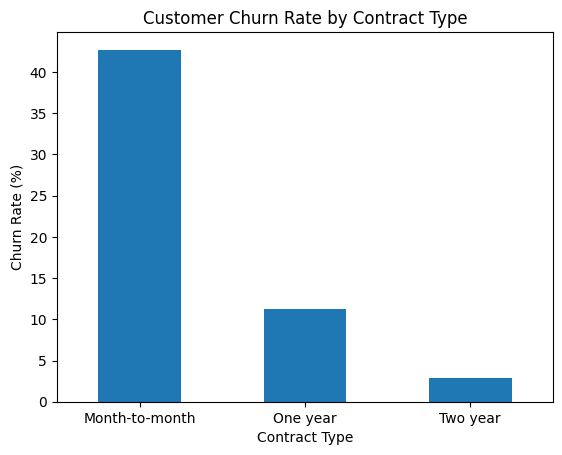

In [ ]:
import matplotlib.pyplot as plt

contract_churn["Yes"].plot(kind="bar")

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Key Insight: Contract Type

Customers on month-to-month contracts have a churn rate of **42.71%**, compared with **11.28%** for one-year contracts and only **2.85%** for two-year contracts.

This suggests that customers with longer-term contracts are substantially more likely to remain with the company. The business could potentially reduce churn by encouraging month-to-month customers to move to longer-term contracts through targeted incentives or loyalty offers.

In [9]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


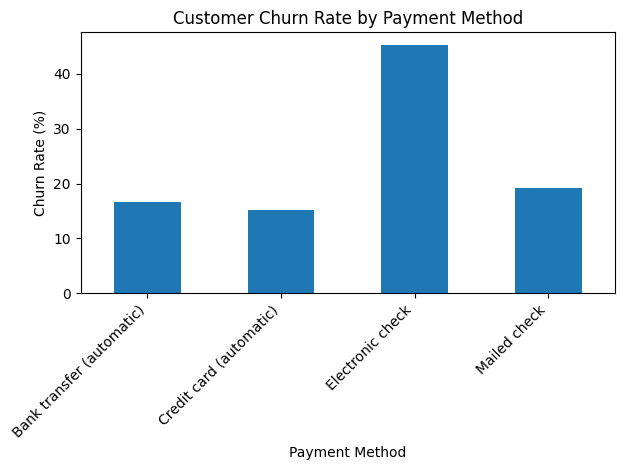

In [10]:
payment_churn["Yes"].plot(kind="bar")

plt.title("Customer Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Key Insight: Payment Method

Customers using electronic checks have the highest churn rate at **45.29%**, compared with **15.25%** for automatic credit card payments, **16.73%** for automatic bank transfers, and **19.20%** for mailed checks.

Electronic check usage is therefore strongly associated with customer churn in this dataset. The company should investigate why these customers are leaving and could consider encouraging customers to adopt automatic payment methods through incentives or a simpler enrollment process.

In [11]:
techsupport_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

techsupport_churn

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


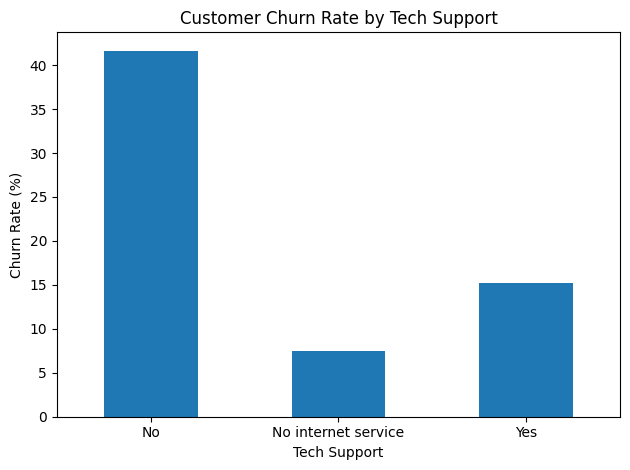

In [12]:
techsupport_churn["Yes"].plot(kind="bar")

plt.title("Customer Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Key Insight: Tech Support

Customers without tech support have a churn rate of **41.65%**, compared with only **15.20%** among customers who have tech support.

This suggests that access to technical support is strongly associated with customer retention. The company could consider promoting tech support services to customers who do not currently have them, particularly customers who already show other indicators of high churn risk.

In [13]:
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.650010
Yes,17.979133


In [14]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"],
    include_lowest=True
)

tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 months,52.321839,47.678161
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


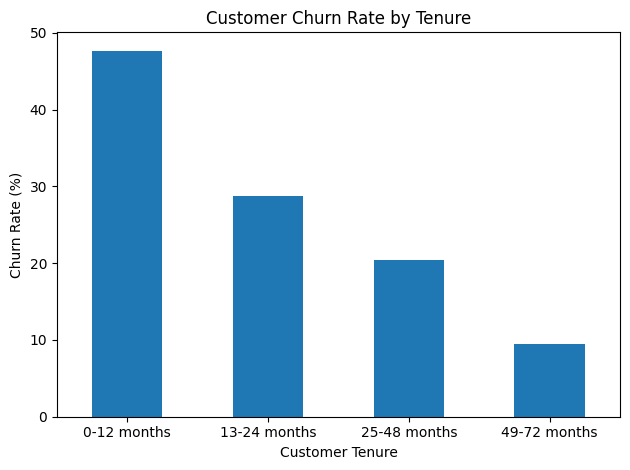

In [15]:
tenure_churn["Yes"].plot(kind="bar")

plt.title("Customer Churn Rate by Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Key Insight: Customer Tenure

Customer churn is highest during the early stages of the customer relationship. Customers with 0–12 months of tenure have a churn rate of **47.68%**, compared with only **9.51%** among customers with 49–72 months of tenure.

This suggests that the first year is a critical period for customer retention. The company could prioritize new-customer onboarding, early engagement, and targeted retention offers during the first 12 months.

## Conclusion and Business Recommendations

The analysis identified several customer characteristics strongly associated with churn. The overall customer churn rate is **26.58%**, meaning approximately one in four customers in the dataset left the company.

### Key Findings

1. **Contract type:** Month-to-month customers have a **42.71% churn rate**, substantially higher than customers on one-year (11.28%) and two-year (2.85%) contracts.

2. **Customer tenure:** Customers in their first 12 months have a **47.68% churn rate**, suggesting that the first year is a critical retention period.

3. **Payment method:** Customers using electronic checks have a **45.29% churn rate**, considerably higher than customers using other payment methods.

4. **Technical support:** Customers without tech support have a **41.65% churn rate**, compared with 15.20% among customers with tech support.

### Recommendations

The company should prioritize retention efforts toward newer, month-to-month customers, particularly those using electronic checks or without technical support.

Potential strategies include:

- Improve onboarding and engagement during the first 12 months.
- Offer incentives for month-to-month customers to switch to longer-term contracts.
- Investigate why electronic-check customers experience higher churn.
- Promote technical support services to customers who do not currently have them.
- Use these churn indicators to identify high-risk customers for targeted retention campaigns.

These findings show associations within the dataset and should not be interpreted as proof that any individual factor directly causes customer churn.